## Speedup of single-core/single-cube scan vs. multi-core/multi-cube scan

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context('paper', font_scale=2., rc={"lines.linewidth": 1.75} )
sns.set_style({'font.weight': 'bold'})

# Markers
plt.rcParams['lines.markersize'] = 11
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['legend.frameon'] = False
plt.rcParams['figure.figsize'] = (8.7,6.27)

_LEGEND_MARKER_SCALE = 1.5
_MARKERS = [".", "^", "v", "<"]

_SNS_PARAMS = {"hue":'S', "style":'S', "markers":_MARKERS, "dashes":True}

palette = [### Colorbrewer colors
"black",
"#c2a5cf",
"#a6dba0",
"#008837",
"#7b3294"]

In [20]:
# Select plot parameters

dtype = "fp16"
s = 128

In [21]:
def add_stats_siso(df, nbytes_out_dtype: int):
    # Input number of bytes per element
    df["in_bytes_per_elem"] = df["dtype"].map({"fp16": 2, "int8": 1})

    df["mem_bytes"] = df["size"] * (df["in_bytes_per_elem"] + nbytes_out_dtype)
    
    df["gelemps"] = (df["size"] / 1e9) / (df["time_us"] / 1e6)
    df["bw_gbps"] = ( df["mem_bytes"] / 1e9) / (df["time_us"] / 1e6)

In [22]:
PREFIX_PATH = "../../../.."

df_scscan = pd.read_csv(f"{PREFIX_PATH}/bench_results_scscan_{s}_{dtype}.csv")
df_scscan["S"] = "ScanU"

df_mcscan = pd.read_csv(f"{PREFIX_PATH}/bench_results_mcscan_{s}_{dtype}.csv")
df_mcscan["S"] = "MCScanU"

df_single_cube = pd.read_csv(f"{PREFIX_PATH}/bench_results_scan_single_cube_{s}_{dtype}.csv")
df_single_cube["S"] = "ScanUL1"

df_multi_cube = pd.read_csv(f"{PREFIX_PATH}/bench_results_scan_multi_cube_{s}_{dtype}.csv")
df_multi_cube["S"] = "MCScanUL1"

df = pd.concat([df_scscan, df_mcscan, df_single_cube, df_multi_cube])

# All four scan variants promote fp16 input to a fp32 output.
add_stats_siso(df, 4)

## Paper plots

/tmp/ipykernel_1771961/1141635741.py:1: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  ax = sns.lineplot(data=df, x='size', y='gelemps', palette=palette, **_SNS_PARAMS)


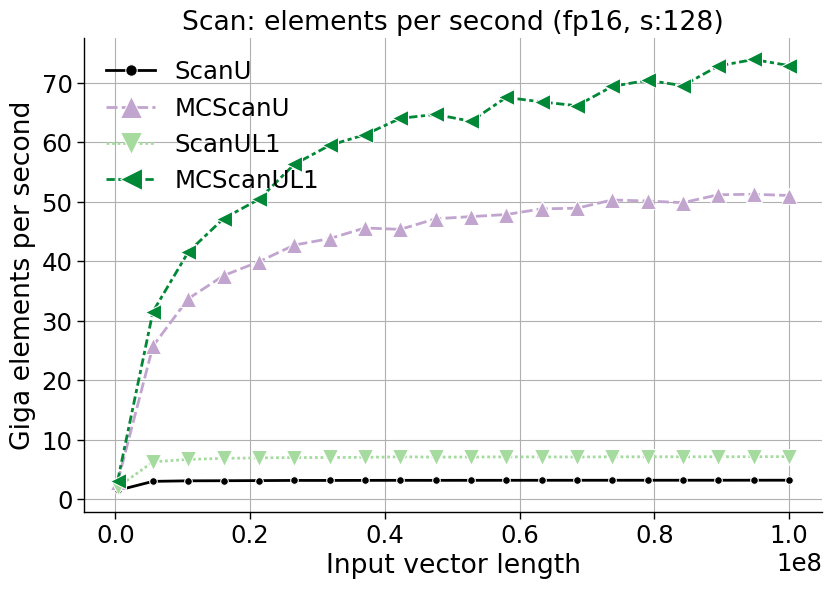

<Figure size 870x627 with 0 Axes>

In [23]:
ax = sns.lineplot(data=df, x='size', y='gelemps', palette=palette, **_SNS_PARAMS)

ax.set_title(f"Scan: elements per second ({dtype}, s:{s})")
ax.set_xlabel("Input vector length")
ax.set_ylabel("Giga elements per second")
sns.despine(right = True)
plt.legend(markerscale=_LEGEND_MARKER_SCALE)
plt.grid()
plt.tight_layout()

fig = ax.get_figure()
fig.savefig(f"scan_single_vs_multi_gelemsps_{dtype}.png")
plt.show()
plt.clf()

In [24]:
def speedup_df(single_df: pd.DataFrame, multi_df: pd.DataFrame, label: str) -> pd.DataFrame:
    merged = pd.merge(
        single_df[["size", "time_us"]],
        multi_df[["size", "time_us"]],
        on="size",
        suffixes=("_single", "_multi"),
    )
    # >1 means the multi-core/cube variant is that many times faster.
    merged["speedup"] = merged["time_us_single"] / merged["time_us_multi"]
    merged["S"] = label
    return merged

speedup_vector = speedup_df(df_scscan, df_mcscan, "ScanU -> MCScanU")
speedup_cube = speedup_df(df_single_cube, df_multi_cube, "ScanUL1 -> MCScanUL1")

speedup = pd.concat([speedup_vector, speedup_cube])
speedup[["S", "size", "time_us_single", "time_us_multi", "speedup"]]

,S,size,time_us_single,time_us_multi,speedup
0,ScanU -> MCScanU,327680,218.50,112.18,1.947763
1,ScanU -> MCScanU,5570560,1847.67,216.28,8.542954
2,ScanU -> MCScanU,10813440,3481.73,320.61,10.859705
3,ScanU -> MCScanU,16056320,5141.40,426.95,12.042160
4,ScanU -> MCScanU,21299200,6771.97,533.11,12.702763
5,ScanU -> MCScanU,26542080,8365.64,621.02,13.470806
6,ScanU -> MCScanU,31784960,10024.86,725.24,13.822817
7,ScanU -> MCScanU,37027840,11641.38,811.63,14.343211
8,ScanU -> MCScanU,42270720,13262.67,931.52,14.237665
9,ScanU -> MCScanU,47513600,14917.55,1007.46,14.807089


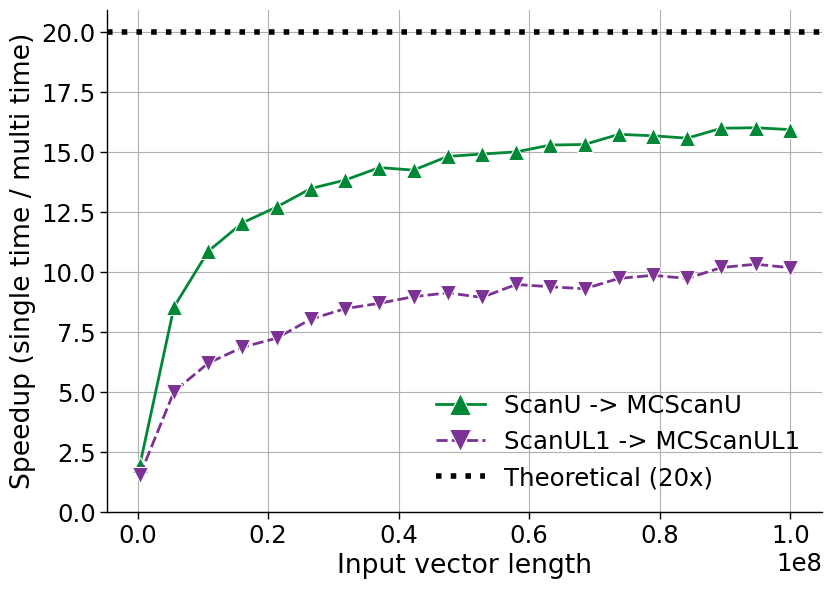

<Figure size 870x627 with 0 Axes>

In [30]:
_SPEEDUP_MARKERS = ["^", "v"]
_SPEEDUP_PALETTE = ["#008837", "#7b3294"]
_NUM_AI_CORES = 20  # Ascend910B4 AI-core count -> theoretical peak multi-core/cube speedup.

ax = sns.lineplot(
    data=speedup, x='size', y='speedup', hue='S', style='S',
    markers=_SPEEDUP_MARKERS, dashes=True, palette=_SPEEDUP_PALETTE,
)
#ax.axhline(1.0, color='black', linestyle='--', linewidth=1)
ax.axhline(_NUM_AI_CORES, color='black', linestyle=':', linewidth=4, label=f"Theoretical ({_NUM_AI_CORES}x)")

ax.set_xlabel("Input vector length")
ax.set_ylabel("Speedup (single time / multi time)")
ax.set_ylim(bottom=0)
sns.despine(right = True)
plt.legend(markerscale=_LEGEND_MARKER_SCALE, loc='lower right')
plt.grid()
plt.tight_layout()

fig = ax.get_figure()
fig.savefig(f"scan_speedup_{dtype}.png")
plt.show()
plt.clf()

In [26]:
speedup.groupby("S")["speedup"].agg(["median", "max"])

,median,max
S,,
ScanU -> MCScanU,14.857006,16.002513
ScanUL1 -> MCScanUL1,9.045083,10.319052
